# Module Investigation
for phase 1 oysters 

Interested to know if there are a subset of genes that drive the relationship we see between modules and factors. Here, I'm going to pull genes within a significantly correlated module and look into their individual GE.

## 0. load libraries

In [2]:
library(tidyverse)
library(pheatmap)
library(RColorBrewer)

## 1. read csvs

### module genes
generated in [WGCNA](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/wgcna/newRef_wgcna_p1.ipynb) for phase 1 oysters

In [3]:
geneInfo <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/p1.wgcna_GeneInfo.csv')
head(geneInfo)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.both,⋯,MMblue,MMgreenyellow,MMyellow,MMblack,MMbrown,MMpink,MMmagenta,MMtan,MMgreen,MMred
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,blue,0.39966747,0.282186775,0.06994163,0.1492213,0.385003047,-0.02872849,0.12634487,⋯,0.3336787,0.09526861,-0.03750345,-0.01178295,-0.04856269,0.115416013,-0.46324802,-0.19648759,0.05033161,-0.04085780
2,LOC111099037,GO:0000978;GO:0000981;GO:0006355,black,-0.02461599,0.002751307,-0.03894892,-0.4217885,-0.363072643,-0.28138410,-0.24659525,⋯,-0.2452065,-0.14257739,-0.16774119,0.34293007,0.31439017,-0.065239565,0.07719106,-0.15380042,0.22565913,0.02356195
3,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,0.44340350,0.303838275,-0.01706141,-0.2141764,0.221972568,-0.34604876,-0.04315846,⋯,0.1248501,0.26055230,0.01693705,0.20241978,0.34095291,0.002859469,-0.37935688,-0.49934818,0.05801009,-0.35374473
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,red,-0.41098524,-0.310348052,-0.04403876,0.3171945,0.004370064,0.34594159,0.31502257,⋯,-0.4530072,-0.51091263,-0.31182848,-0.07876548,0.07063991,0.365824475,0.50638260,0.32368892,0.40288267,0.68022795
5,LOC111099050,GO:0005515;GO:0006886;GO:0031462;GO:0043161;GO:1990756,green,-0.35176148,-0.282846525,-0.03894228,-0.0592647,-0.254057873,0.06198487,-0.01882029,⋯,-0.3888532,-0.68292735,-0.49529157,0.14867298,0.47087567,-0.253669949,0.40577513,0.03737518,0.72387889,0.49103455
6,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,blue,0.43025668,0.181368789,-0.15299170,-0.3250255,0.370840965,-0.54214175,-0.10090793,⋯,0.7387194,0.17197754,0.25907960,0.07602426,-0.20551234,-0.602026100,-0.33485347,-0.05929480,-0.20905792,-0.29068175


### vst
generated in [DESeq analysis](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/filter_deseq_p1.v.p1.ipynb) for phase 1 oysters

In [4]:
vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1_vst.csv')
head(vst)

,X,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,11.217975,11.934767,11.224763,11.385998,11.491494,11.330413,11.619094,11.599610,10.935631,⋯,11.695721,11.157977,11.658281,11.998989,11.369555,11.484610,11.158177,11.698655,11.463655,11.597431
2,LOC144621269,9.238570,14.233747,13.248661,6.734822,7.542979,13.067731,11.252050,11.655097,11.695209,⋯,13.172456,11.238048,8.354464,15.534626,13.113269,11.584691,11.875265,13.441989,6.077703,12.341027
3,LOC111120925,6.162650,6.596958,6.709412,6.097391,6.365111,6.642652,8.868688,8.893482,8.281309,⋯,8.933040,6.529973,8.449891,8.330386,6.304683,8.790027,6.259740,6.294474,5.806396,6.516750
4,LOC144621283,9.891478,10.157309,10.265604,9.957131,10.370479,10.049745,9.730975,10.158138,10.091135,⋯,10.091122,9.802983,9.406153,9.831201,9.297184,10.572628,10.579026,9.655386,10.115723,10.146704
5,LOC144621276,13.540965,13.766144,14.145528,13.224735,13.084951,13.044656,13.810034,13.596797,13.309595,⋯,13.929735,13.686105,12.877924,13.996777,12.961637,13.892552,14.181140,13.333327,13.928741,13.550413
6,LOC111115920,8.717293,8.463000,8.350118,8.954966,9.308119,8.469442,7.913170,8.149178,8.357417,⋯,7.567075,8.159515,8.690883,8.016850,7.795664,8.011123,8.435333,8.088760,8.136625,7.770861


### meta data

In [5]:
growth <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase1_weights.csv')

# need to convert sample names to be consistent with my naming convention
growth$Sample <- paste0(substr(growth$Phase_1_treat, 1, 1), growth$Phase_1_rep, '_Nu_', growth$Tag_color, growth$Tag_num)

growth <- growth %>% select(Sample, 
                            Phase_1_treat, 
                            Phase_1_temp, 
                            Phase_1_DO, 
                            Actual_tissue_growth_mg, 
                            Actual_shell_growth_mg, 
                            Ratio_tissue_shell_mg)

head(growth)

,Sample,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B1_Nu_O1,Both,Warm,Hyp,21.92322,42.27678,0.518564091
2,B1_Nu_O2,Both,Warm,Hyp,42.34732,63.65268,0.665287306
3,B1_Nu_O3,Both,Warm,Hyp,27.91340,77.58660,0.359770888
4,B1_Nu_O4,Both,Warm,Hyp,148.21004,157.38996,0.941674043
5,B1_Nu_O5,Both,Warm,Hyp,-40.02418,-19.47582,2.055070339
6,B1_Nu_O6,Both,Warm,Hyp,117.50070,181.29930,0.64810344


## 2. pull vst for sig. modules
for phase 1 oysters, only 3 modules were significantly correlated with factors:
1. red - negatively correlated with tissue growth
2. blue - positively correlated with shell growth and warm treatment
3. black - negatively correlated with temperature 

### red module
negatively correlated with tissue growth

In [6]:
# pull red genes
red_genes <- geneInfo %>% 
filter(ModuleColor == 'red') %>% 
pull(Gene)

length(red_genes) # 714 genes in the red module

[1] 714

In [7]:
# vst for red genes
red_vst <- vst[vst$X %in% red_genes,]

dim(red_vst)
head(red_vst)

[1] 714  24

,X,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,LOC111115920,8.717293,8.463000,8.350118,8.954966,9.308119,8.469442,7.913170,8.149178,8.357417,⋯,7.567075,8.159515,8.690883,8.016850,7.795664,8.011123,8.435333,8.088760,8.136625,7.770861
28,LOC144621380,6.058625,5.994939,6.935630,7.208055,6.460044,7.237841,6.150863,5.806396,6.100498,⋯,6.378398,5.806396,6.507428,5.806396,5.806396,6.103320,5.806396,5.806396,6.189521,6.022544
32,LOC144621432,6.308952,6.940086,6.527167,7.398793,7.336255,6.543788,7.165230,6.965072,7.020207,⋯,6.520822,7.073280,7.195036,6.623070,7.401454,7.641880,6.964963,7.604984,6.900280,6.903925
41,LOC111103347,9.413272,7.663363,10.065039,8.618184,9.153819,8.953713,7.030178,7.969784,7.533388,⋯,7.383929,6.926428,9.049808,9.238389,8.171709,7.323465,8.229837,8.689587,7.765698,7.998517
68,LOC111113944,9.542408,9.384007,11.779428,7.858441,12.174277,7.947743,9.336927,9.194138,10.162571,⋯,7.479042,6.769405,11.308528,9.955325,11.049143,8.591347,8.721385,11.078278,9.065616,12.106679
71,LOC111104490,8.671672,8.397217,8.632301,8.709299,9.535117,9.121980,8.441319,8.497272,9.122812,⋯,8.894432,9.458515,8.555458,8.742212,8.739748,8.380591,8.168351,8.882738,8.488917,8.465623


In [8]:
# convert vst to long format
red_vst.long <- red_vst %>%
pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst') %>%
rename(Gene = X)

head(red_vst.long)

Gene,Sample,vst
<chr>,<chr>,<dbl>
LOC111115920,B1_Nu_O03,8.717293
LOC111115920,B2_Nu_O12,8.463000
LOC111115920,B4_Nu_O32,8.350118
LOC111115920,B5_Nu_O36,8.954966
LOC111115920,B6_Nu_O47,9.308119
LOC111115920,C1_Nu_W01,8.469442


In [9]:
# add growth info
red_vst_growth <- merge(red_vst.long, growth, by = 'Sample')
head(red_vst_growth)

,Sample,Gene,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B2_Nu_O12,LOC111107507,7.419190,Both,Warm,Hyp,80.377,150.423,0.534339828
2,B2_Nu_O12,LOC144627835,6.785863,Both,Warm,Hyp,80.377,150.423,0.534339828
3,B2_Nu_O12,LOC111125192,10.549486,Both,Warm,Hyp,80.377,150.423,0.534339828
4,B2_Nu_O12,LOC144627284,7.344560,Both,Warm,Hyp,80.377,150.423,0.534339828
5,B2_Nu_O12,LOC111125159,9.679906,Both,Warm,Hyp,80.377,150.423,0.534339828
6,B2_Nu_O12,LOC111107064,12.518372,Both,Warm,Hyp,80.377,150.423,0.534339828


#### plot growth vs. module expression

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


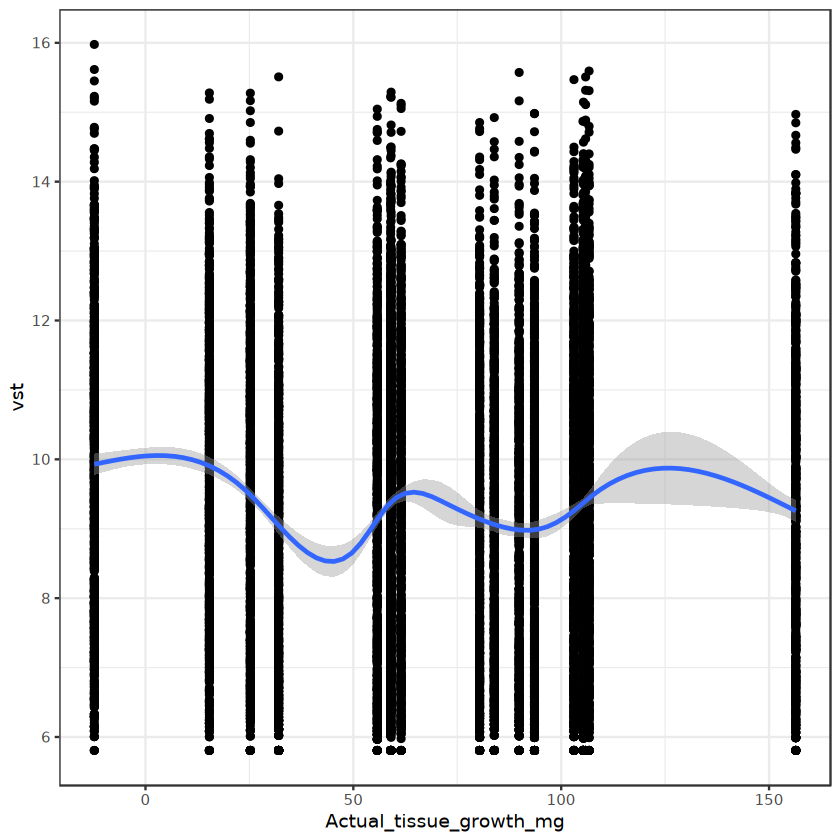

In [10]:
ggplot(red_vst_growth, aes(x = Actual_tissue_growth_mg, y = vst)) +
geom_point() +
geom_smooth() +
theme_bw()

#### hub gene: LOC111135053

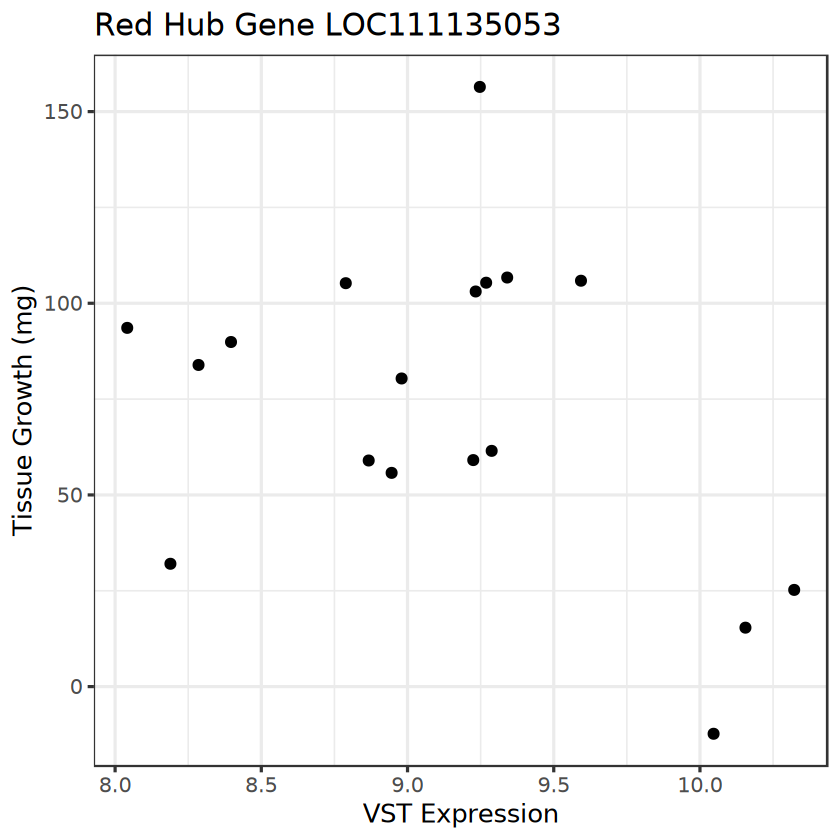

In [11]:
red_hubGene <- red_vst_growth %>% filter(Gene == 'LOC111135053')

ggplot(red_hubGene, aes(x = vst, y = Actual_tissue_growth_mg)) +
geom_point() +
labs(x = 'VST Expression',
     y = 'Tissue Growth (mg)',
     title = 'Red Hub Gene LOC111135053') +
theme_bw(base_size = 15)

### blue module
positively correlated with shell growth and temperature treatment

In [12]:
# pull red genes
blue_genes <- geneInfo %>% 
filter(ModuleColor == 'blue') %>% 
pull(Gene)

length(blue_genes) # 1149 genes in the red module

[1] 1149

In [13]:
# vst for red genes
blue_vst <- vst[vst$X %in% blue_genes,]

dim(blue_vst)
head(blue_vst)

[1] 1149   24

,X,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
42,LOC111103350,9.010443,7.060082,9.039641,8.195446,8.614067,8.272462,7.617818,6.980232,7.958207,⋯,10.565649,6.995920,7.781420,8.054730,8.179476,11.039693,8.958540,8.397802,7.278678,7.435651
48,LOC111103667,10.683765,10.159731,10.098630,9.894236,9.931693,11.179419,10.514259,9.775269,10.156670,⋯,10.240149,10.053264,10.341467,9.888592,10.469400,11.013350,10.880907,10.334288,10.804500,10.057273
53,LOC144621561,5.806396,7.189715,6.996165,6.594821,7.210938,6.762428,5.806396,5.806396,7.353748,⋯,7.280236,6.597423,6.422614,5.806396,6.734561,7.946745,6.866035,6.948629,6.611047,7.258738
67,LOC144621743,7.357536,8.691806,7.834363,7.154715,9.660346,7.920388,7.843740,7.311516,8.192720,⋯,8.776053,7.634487,8.043508,8.268182,8.363767,8.874120,7.507840,8.533109,8.014646,8.273622
146,LOC144619181,5.984862,6.834983,7.096549,6.265342,5.806396,11.116238,6.461914,5.806396,5.806396,⋯,11.749544,5.806396,9.531418,5.806396,5.806396,12.013272,6.978286,6.176098,7.224374,9.446437
148,LOC111105167,8.196331,7.189715,5.806396,7.503663,6.982631,6.660921,5.806396,5.806396,7.421640,⋯,6.849611,5.806396,7.040880,5.806396,6.888116,6.947474,8.036163,6.717943,5.998381,6.237491


In [14]:
# convert vst to long format
blue_vst.long <- blue_vst %>%
pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst') %>%
rename(Gene = X)

head(blue_vst.long)

Gene,Sample,vst
<chr>,<chr>,<dbl>
LOC111103350,B1_Nu_O03,9.010443
LOC111103350,B2_Nu_O12,7.060082
LOC111103350,B4_Nu_O32,9.039641
LOC111103350,B5_Nu_O36,8.195446
LOC111103350,B6_Nu_O47,8.614067
LOC111103350,C1_Nu_W01,8.272462


In [15]:
# add growth info
blue_vst_growth <- merge(blue_vst.long, growth, by = 'Sample')
head(blue_vst_growth)

,Sample,Gene,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B2_Nu_O12,LOC111103890,9.195064,Both,Warm,Hyp,80.377,150.423,0.534339828
2,B2_Nu_O12,LOC111104297,6.132500,Both,Warm,Hyp,80.377,150.423,0.534339828
3,B2_Nu_O12,LOC111105066,10.143913,Both,Warm,Hyp,80.377,150.423,0.534339828
4,B2_Nu_O12,LOC111134008,10.879506,Both,Warm,Hyp,80.377,150.423,0.534339828
5,B2_Nu_O12,LOC111103288,9.001727,Both,Warm,Hyp,80.377,150.423,0.534339828
6,B2_Nu_O12,LOC111103981,9.965668,Both,Warm,Hyp,80.377,150.423,0.534339828


#### plot growth vs. module expression

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
Warning message:
“Failed to fit group 1.
Caused by error in `smooth.construct.cr.smooth.spec()`:
! x has insufficient unique values to support 10 knots: reduce k.”
Warning message:
“Failed to fit group 2.
Caused by error in `smooth.construct.cr.smooth.spec()`:
! x has insufficient unique values to support 10 knots: reduce k.”


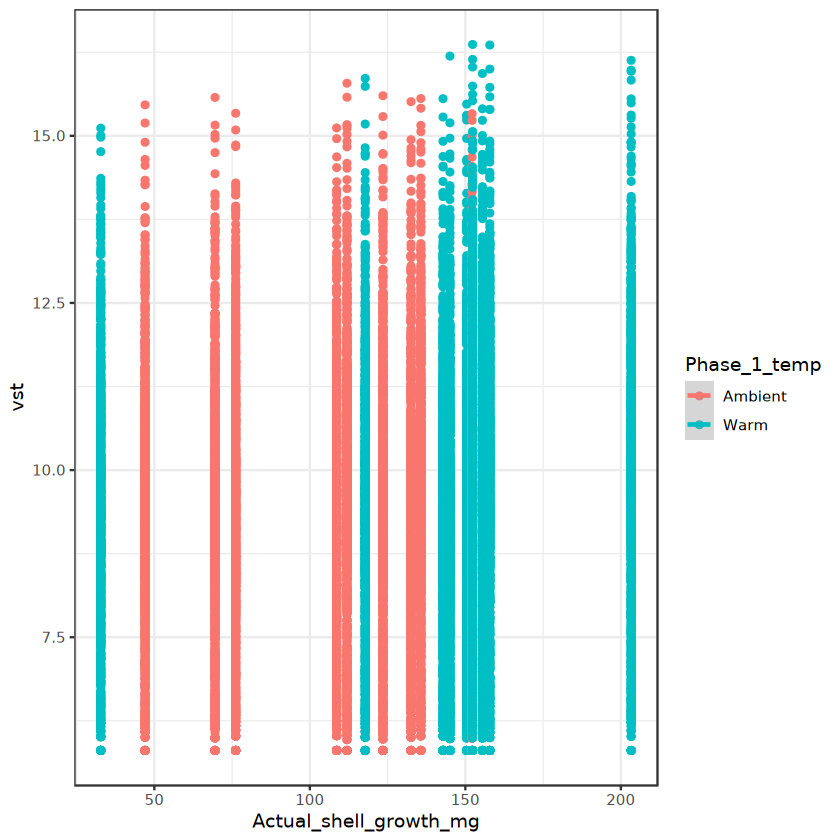

In [16]:
ggplot(blue_vst_growth, aes(x = Actual_shell_growth_mg, y = vst, col = Phase_1_temp)) +
geom_point() +
geom_smooth() +
theme_bw()

#### hub gene: LOC111118049
[LOC111118049](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111118049): eukaryotic translation initiation factor 2 subunit 1-like 
- enables RNA binding, ribosome binding, translation initiation factory activity
- involved in translational initiation

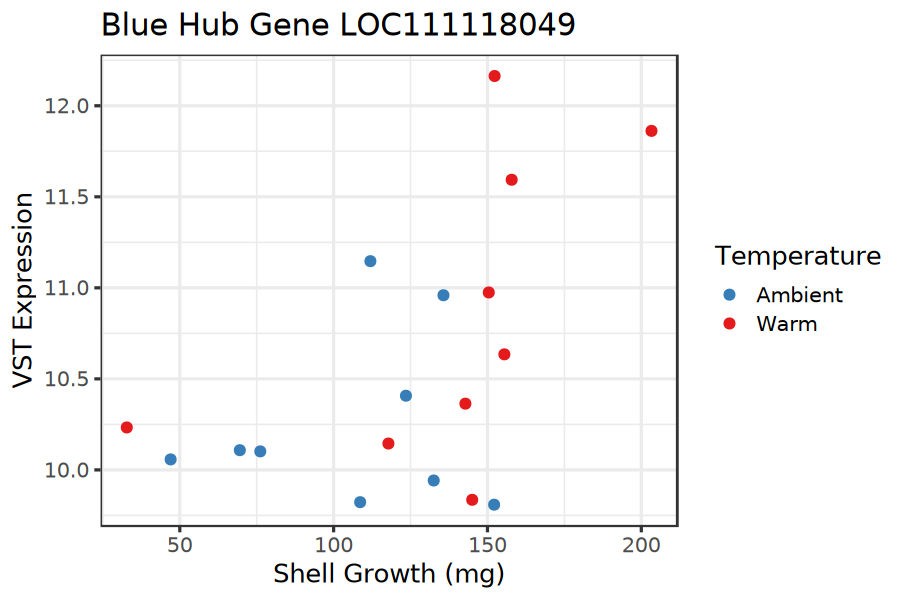

In [17]:
options(repr.plot.width = 7.5, repr.plot.height = 5)

blue_hubGene <- blue_vst_growth %>% filter(Gene == 'LOC111118049')

ggplot(blue_hubGene, aes(x = vst, y = Actual_shell_growth_mg, col = Phase_1_temp)) +
geom_point() +
scale_color_brewer(palette = 'Set1', direction = -1) +
labs(x = 'VST Expression',
     y = 'Shell Growth (mg)',
     col = 'Temperature',
     title = 'Blue Hub Gene LOC111118049') +
coord_flip() +
theme_bw(base_size = 15)

it does appear that higher expression of this gene does correlate with increased shell growth

#### heatmap

but first, need to look at the correlation between treatment and shell growth - because if there is a correlation, then the traits are confounding

In [18]:
growth$temp_binary <- ifelse(growth$Phase_1_temp == "Warm", 1, 0)
cor.test(growth$Actual_shell_growth_mg, growth$temp_binary)


	Pearson's product-moment correlation

data:  growth$Actual_shell_growth_mg and growth$temp_binary
t = -1.4708, df = 190, p-value = 0.143
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.24403970  0.03605201
sample estimates:
       cor 
-0.1060979 


so appears that there is no significant correlation between shell growth and warm treatment

need to pull out gene significance for shell growth and temperature treatment

In [19]:
blue_gs <- geneInfo %>% 
select(Gene, GO.terms, ModuleColor, GS.Actual_shell_growth_mg, GS.warm, p.GS.GS.Actual_shell_growth_mg, p.GS.GS.warm) %>%
filter(ModuleColor == 'blue')

head(blue_gs)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.warm,p.GS.GS.Actual_shell_growth_mg,p.GS.GS.warm
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,blue,0.39966747,0.31929640,0.05882963,0.137519691
2,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,0.44340350,0.29305474,0.03407378,0.174755141
3,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,blue,0.43025668,0.51665255,0.04043220,0.011597196
4,LOC111099056,GO:0003723;GO:0006396;GO:0008173,blue,0.04069859,0.05234405,0.85371948,0.812504555
5,LOC111099067,GO:0000463;GO:0005634;GO:0008650;GO:0030687;GO:0031167,blue,0.33300808,0.38777609,0.12049730,0.067505091
6,LOC111099690,GO:0009226;GO:0050577,blue,0.46954235,0.53354451,0.02378955,0.008743777


gene significance = correlation (-1:1), strength and direction, between trait and that gene

the corresponding pvalue tells you how likely you'd obverse a correlation that large by chance alone

I want to make a df that pulls genes, and determines if they're temp-associated (warm pval < 0.05), growth-associated (growth pval < 0.05), both, or neither (and therefore a module member only)

In [34]:
blue_gs2 <- blue_gs %>%
mutate(geneClass = case_when(
    p.GS.GS.Actual_shell_growth_mg < 0.05 & p.GS.GS.warm > 0.05 ~ 'Growth',
    p.GS.GS.Actual_shell_growth_mg > 0.05 & p.GS.GS.warm < 0.05 ~ 'Warm',
    p.GS.GS.Actual_shell_growth_mg > 0.05 & p.GS.GS.warm > 0.05 ~ 'Neither',
    p.GS.GS.Actual_shell_growth_mg < 0.05 & p.GS.GS.warm < 0.05 ~ 'Both'))

head(blue_gs2)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.warm,p.GS.GS.Actual_shell_growth_mg,p.GS.GS.warm,geneClass
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,blue,0.39966747,0.31929640,0.05882963,0.137519691,Neither
2,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,0.44340350,0.29305474,0.03407378,0.174755141,Growth
3,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,blue,0.43025668,0.51665255,0.04043220,0.011597196,Both
4,LOC111099056,GO:0003723;GO:0006396;GO:0008173,blue,0.04069859,0.05234405,0.85371948,0.812504555,Neither
5,LOC111099067,GO:0000463;GO:0005634;GO:0008650;GO:0030687;GO:0031167,blue,0.33300808,0.38777609,0.12049730,0.067505091,Neither
6,LOC111099690,GO:0009226;GO:0050577,blue,0.46954235,0.53354451,0.02378955,0.008743777,Both


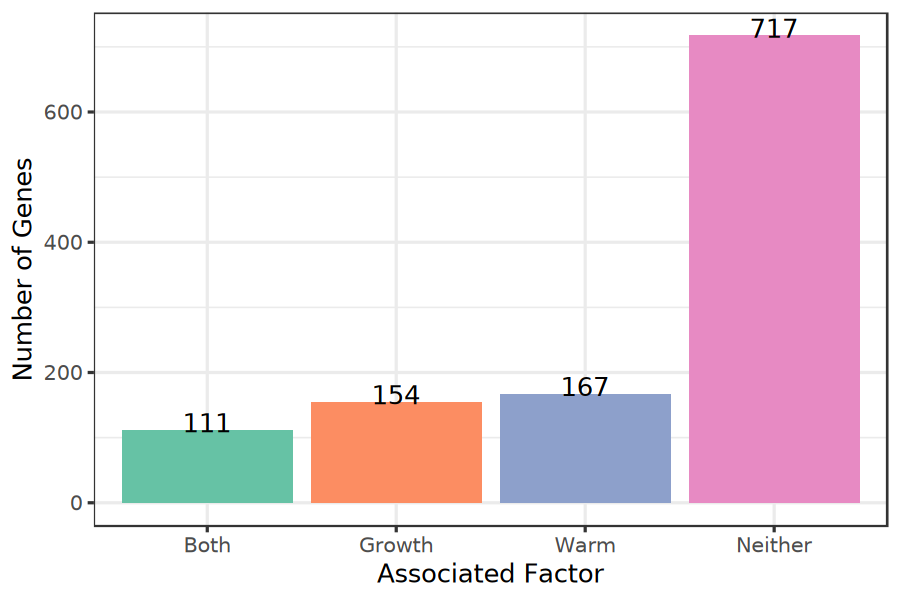

In [38]:
blue_gs2$geneClass <- factor(blue_gs2$geneClass, levels = c('Both', 'Growth', 'Warm', 'Neither'))

ggplot(blue_gs2, aes(x = geneClass, fill = geneClass)) +
geom_bar() +
geom_text(
    stat = "count", 
    aes(label = after_stat(count)),
    vjust = 0.1
  ) +
scale_fill_brewer(palette = 'Set2') +
guides(fill = 'none') +
labs(x = 'Associated Factor',
     y = 'Number of Genes') +
theme_bw(base_size = 15)

interesting - so the majority of the genes in the blue module are not significantly correlated with the temperature treatment/shell growth, but are instead just members of the module (not sure how that works? it's just that they're connected in the network? and so they're not drivers of the module relationship?)

but we see genes separate into those that are associated with only the warm treatment, only shell growth, and those associated with both shell growth and the warm treatment

should plot heatmap of GS correlations for these and pull out each of the gene classes and look at what they're enriched for 

In [42]:
blue.matrix <- blue_gs2 %>% select(Gene, GS.Actual_shell_growth_mg, GS.warm) %>% column_to_rownames('Gene')
head(blue.matrix)

,GS.Actual_shell_growth_mg,GS.warm
,<dbl>,<dbl>
LOC111099029,0.39966747,0.31929640
LOC111099039,0.44340350,0.29305474
LOC111099053,0.43025668,0.51665255
LOC111099056,0.04069859,0.05234405
LOC111099067,0.33300808,0.38777609
LOC111099690,0.46954235,0.53354451


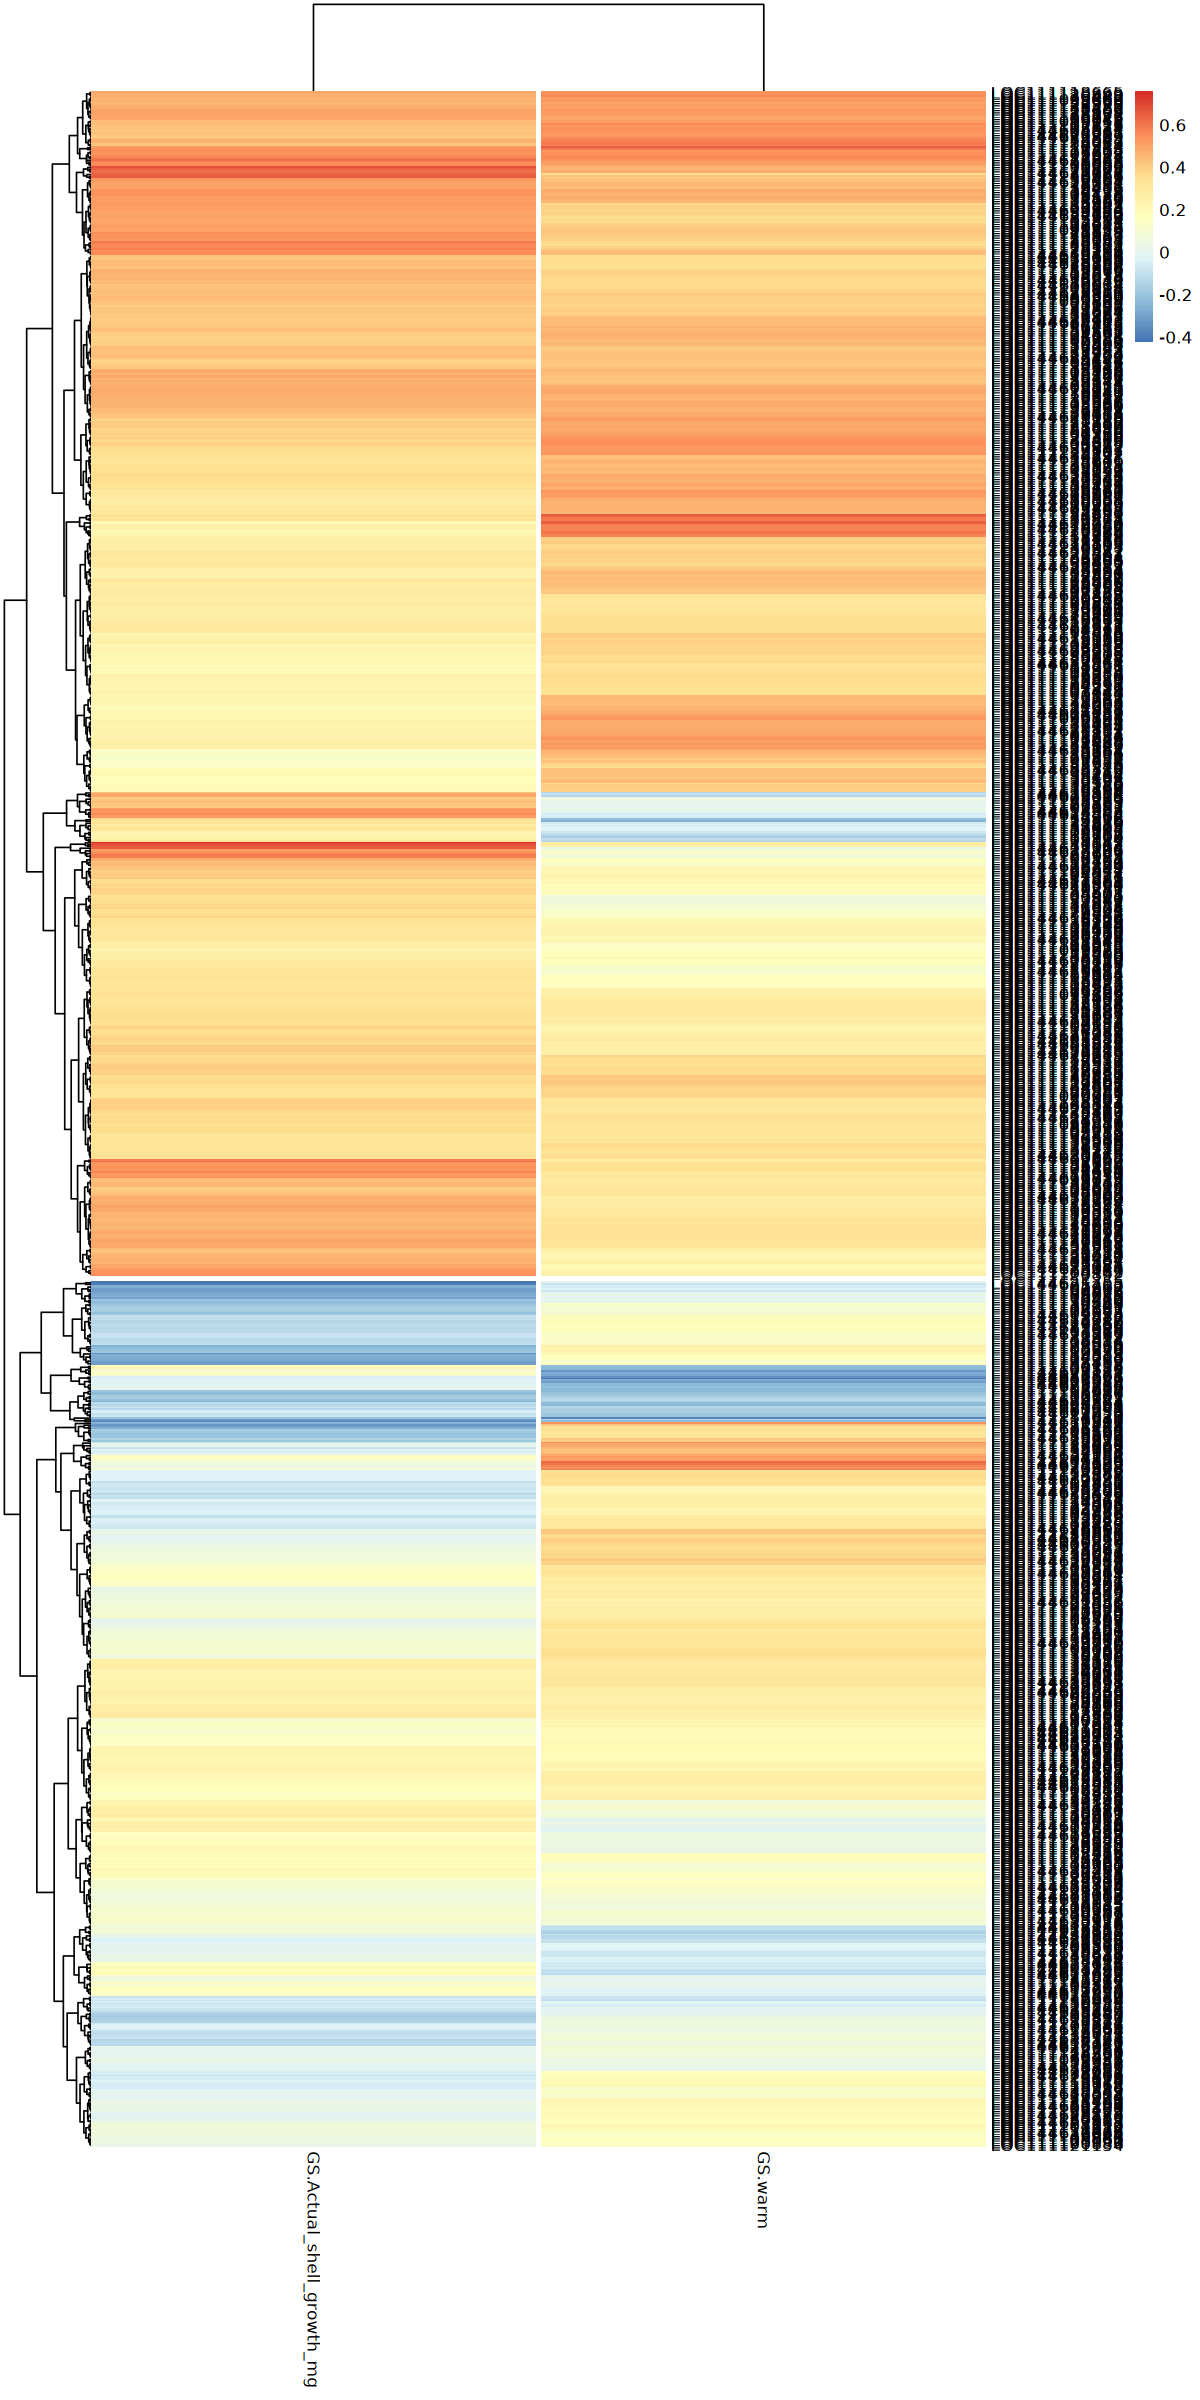

In [51]:
options(repr.plot.height = 20, repr.plot.width = 10)

pheatmap(blue.matrix,
         cutree_rows = 2, 
         cutree_cols = 2
        )

would probably be interesting to pull the genes that have opposing patterns for shell growth and warm treatment - those that are dark blue for one factor and dark red for another

looks like there's a similar group of genes that drive the positive correlation between the module and the traits (especially the top portion with red genes)

but then there's a group of genes that have lower expression with increased shell growth, but continue to have higher expression in the warm treatments - what could this mean???? maybe that's why we don't see a correlation between warm and increased shell growth, bc the continued expression of these genes offsets effects of warming? 

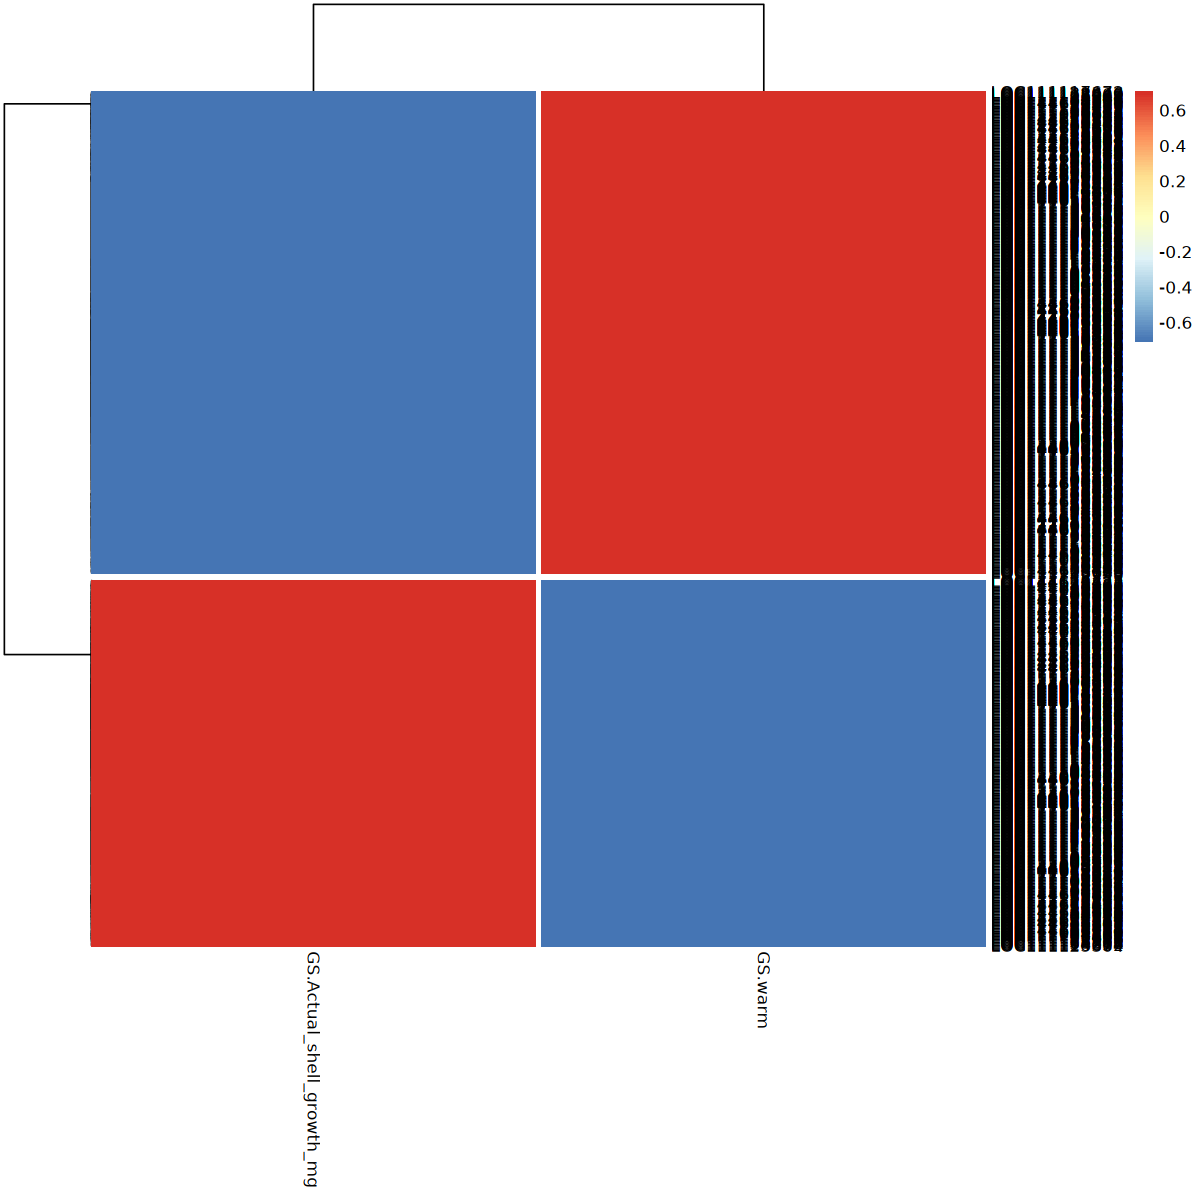

In [53]:
options(repr.plot.height = 10, repr.plot.width = 10)

pheatmap(blue.matrix,
         cutree_rows = 2, 
         cutree_cols = 2,
        scale = 'row' # standardizes each gene separately across samples
        )

okay so when i include scaling rows, we see that genes segregate into two separate categories - those that drive the relationship between the module and shell growth and those between the module and warm treatment (although seems like that can't be right to be all or nothing like that for every gene)

#### growth associated genes

based on the plots above, pulling out the genes associated with growth and plotting the VST expression against growth

In [56]:
growth_blue <- blue_gs2 %>%
filter(geneClass == 'Growth')

dim(growth_blue)
head(growth_blue)

[1] 154   8

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.warm,p.GS.GS.Actual_shell_growth_mg,p.GS.GS.warm,geneClass
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,0.4434035,0.293054735,0.03407378,0.17475514,Growth
2,LOC111099808,GO:0005730;GO:0005737;GO:0006364;GO:0030515;GO:0030688,blue,0.4388059,0.404216738,0.03620038,0.05574759,Growth
3,LOC111100042,GO:0003746;GO:0003924;GO:0005525;GO:0005739;GO:0070125,blue,0.5140391,0.409536199,0.01210021,0.05230340,Growth
4,LOC111100187,GO:0016791,blue,0.4885881,0.177150056,0.01799983,0.41872843,Growth
5,LOC111103461,GO:0005737;GO:0006446;GO:0140469,blue,0.4262199,0.006394372,0.04256076,0.97689940,Growth
6,LOC111103502,GO:0030336;GO:0070822,blue,0.4654024,0.255183780,0.02522692,0.23993393,Growth


In [57]:
# vst for red genes
growth_blue.vst <- vst[vst$X %in% growth_blue$Gene,]

dim(growth_blue.vst)
head(growth_blue.vst)

[1] 154  24

,X,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
48,LOC111103667,10.683765,10.159731,10.098630,9.894236,9.931693,11.179419,10.514259,9.775269,10.156670,⋯,10.240149,10.053264,10.341467,9.888592,10.469400,11.013350,10.880907,10.334288,10.804500,10.057273
53,LOC144621561,5.806396,7.189715,6.996165,6.594821,7.210938,6.762428,5.806396,5.806396,7.353748,⋯,7.280236,6.597423,6.422614,5.806396,6.734561,7.946745,6.866035,6.948629,6.611047,7.258738
146,LOC144619181,5.984862,6.834983,7.096549,6.265342,5.806396,11.116238,6.461914,5.806396,5.806396,⋯,11.749544,5.806396,9.531418,5.806396,5.806396,12.013272,6.978286,6.176098,7.224374,9.446437
225,LOC111103502,11.700147,10.736952,11.110010,10.695043,11.265381,12.256850,12.478580,11.452670,11.855261,⋯,12.725921,10.708294,10.325209,11.224593,12.331046,11.996568,11.668517,11.456402,11.555032,11.190396
262,LOC111104038,10.509486,9.920636,9.222650,9.830271,10.190310,11.050758,9.686566,9.821720,10.125787,⋯,10.402606,9.597827,9.342614,9.709018,10.510050,11.027405,10.692797,10.327030,10.379714,9.438557
333,LOC111104074,9.912238,9.590930,9.707956,9.676980,9.567977,10.598422,9.968794,9.712721,10.201305,⋯,9.654284,9.839797,9.432538,9.163552,9.748946,10.347101,10.305544,9.964795,10.458273,9.046769


In [58]:
# convert vst to long format
growth_blue.vst.long <- growth_blue.vst %>%
pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst') %>%
rename(Gene = X)

head(growth_blue.vst.long)

Gene,Sample,vst
<chr>,<chr>,<dbl>
LOC111103667,B1_Nu_O03,10.683765
LOC111103667,B2_Nu_O12,10.159731
LOC111103667,B4_Nu_O32,10.098630
LOC111103667,B5_Nu_O36,9.894236
LOC111103667,B6_Nu_O47,9.931693
LOC111103667,C1_Nu_W01,11.179419


In [59]:
# add growth info
growth_blue_meta <- merge(growth_blue.vst.long, growth, by = 'Sample')
head(growth_blue_meta)

,Sample,Gene,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg,temp_binary
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
1,B2_Nu_O12,LOC111130301,13.062511,Both,Warm,Hyp,80.377,150.423,0.534339828,1
2,B2_Nu_O12,LOC111105386,7.885798,Both,Warm,Hyp,80.377,150.423,0.534339828,1
3,B2_Nu_O12,LOC111130093,9.662891,Both,Warm,Hyp,80.377,150.423,0.534339828,1
4,B2_Nu_O12,LOC111120848,9.700060,Both,Warm,Hyp,80.377,150.423,0.534339828,1
5,B2_Nu_O12,LOC111138014,12.955660,Both,Warm,Hyp,80.377,150.423,0.534339828,1
6,B2_Nu_O12,LOC111103667,10.159731,Both,Warm,Hyp,80.377,150.423,0.534339828,1


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


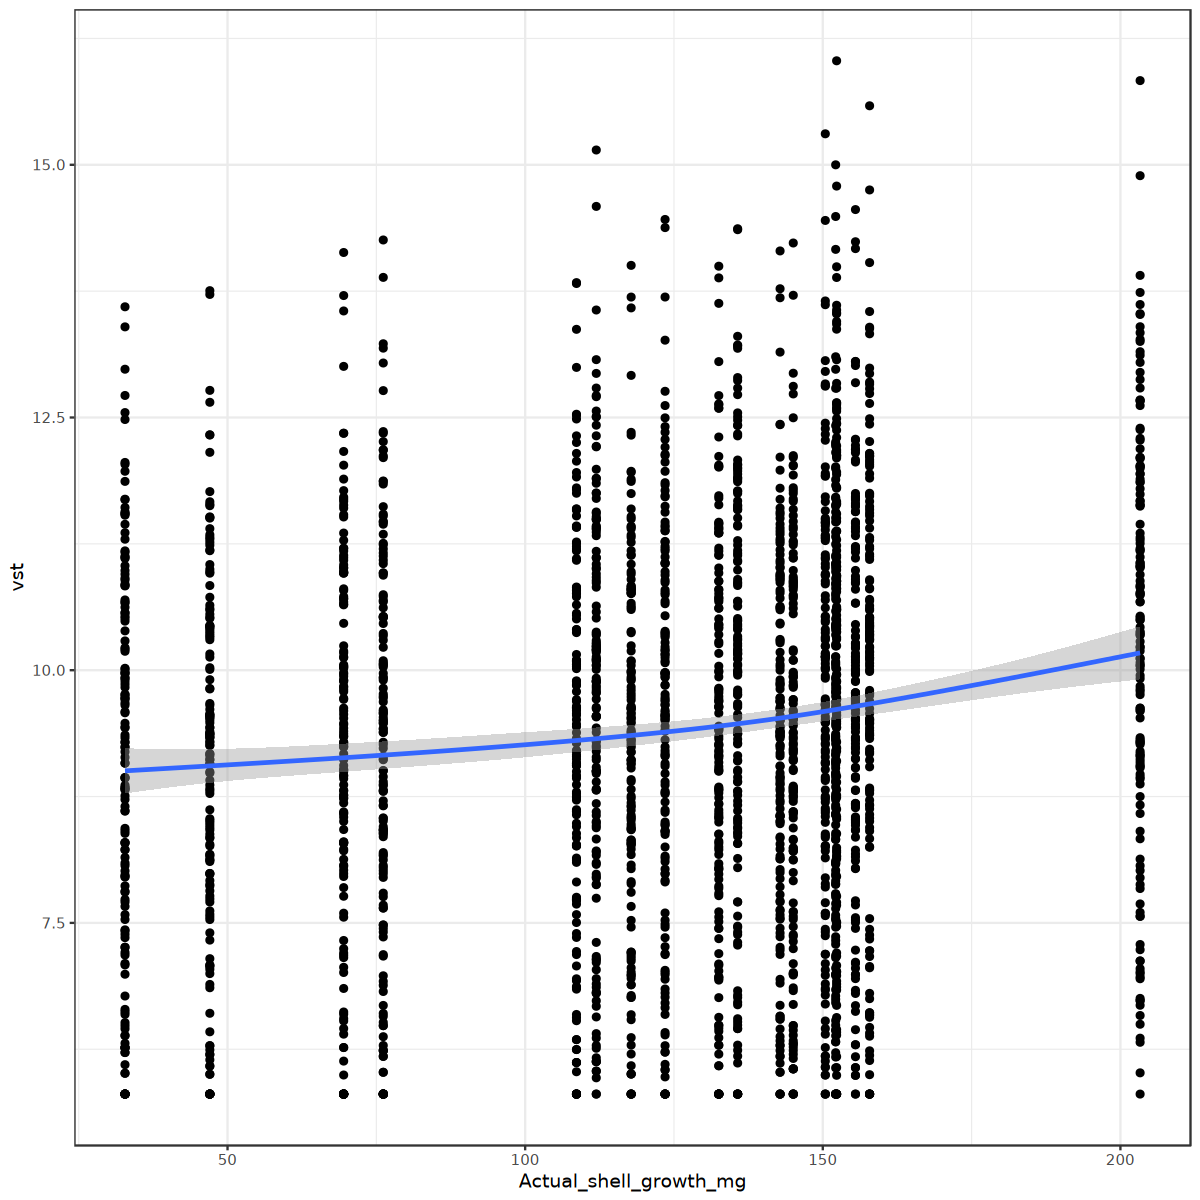

In [64]:
ggplot(growth_blue_meta, aes(x = Actual_shell_growth_mg, y = vst)) +
geom_point() +
geom_smooth() +
theme_bw()

when considering all of the genes associated with growth in this module, we see a general increase in expression with an increase in shell growth (but it's not super strong)

what if i pull out the top 20 genes with the strongest correlations with growth?

In [ ]:
head(growth_blue)

In [72]:
growth_blue[order(growth_blue$GS.Actual_shell_growth_mg, decreasing = TRUE),]

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.warm,p.GS.GS.Actual_shell_growth_mg,p.GS.GS.warm,geneClass
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
24,LOC111111645,GO:0005515;GO:0008270,blue,0.7579268,0.28472201,2.798334e-05,0.18791154,Growth
84,LOC111130112,GO:0000070;GO:0005737;GO:0005828;GO:0007094;GO:0031267;GO:1903394;GO:1990423,blue,0.6957640,0.30876756,2.274619e-04,0.15170835,Growth
109,LOC111135064,GO:0005509;GO:0005874;GO:0010975,blue,0.6687309,0.25801921,4.857048e-04,0.23456999,Growth
154,LOC144627594,GO:0000209;GO:0005515;GO:0043161;GO:0061630,blue,0.6616751,0.03646948,5.848271e-04,0.86878477,Growth
89,LOC111130439,GO:0005814;GO:0060271;GO:0097730,blue,0.6557038,0.40287001,6.818569e-04,0.05664669,Growth
92,LOC111130667,GO:0004333;GO:0005739;GO:0006099;GO:0006106;GO:0006108,blue,0.6462309,0.36544745,8.641299e-04,0.08638590,Growth
95,LOC111132900,GO:0005737;GO:0008525;GO:0008526;GO:0015914;GO:0031210;GO:0035091,blue,0.6104151,0.29873496,1.979363e-03,0.16616057,Growth
13,LOC111104993,GO:0005515;GO:0005615,blue,0.6007936,0.09603270,2.432771e-03,0.66292170,Growth
73,LOC111128143,GO:0000287;GO:0004449;GO:0005739;GO:0006099;GO:0006102;GO:0051287,blue,0.5981487,0.37345290,2.571806e-03,0.07921070,Growth
